# 📈 **Mulpiple Linear Regression**

# **Making Predictions with Multiple Linear Regression**

Let’s make this concrete with an example. Imagine we are predicting age (y) from height (x1) and weight (x2). Our multiple linear regression model representation for this problem would be:

**y = B0 + B1 * x1 + B2 * x2**

or

**age =B0 + B1 * height + B2 * weight**

Where B0 is the bias coefficient and B1 and B2 are the coefficients for the height and weight column. We use a learning technique to find a good set of coefficient values. Once found, we can plug in different height and weight values to predict the age.

For example, lets use B0 = 0.1, B1 = 0.3 and B2 = 0.4. Let’s plug them in and calculate the age (in years) for a person with the height of 160 centimeters and weight of 60 kg.

age = 0.1 + 0.3 * 160 + 0.4 * 60

age = 72.1


# 📤 Import & Install Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn import metrics

from sklearn.linear_model import LinearRegression

%matplotlib inline

## 💾 Check out the Data

In [ ]:
df = pd.read_csv('Real estate.csv')

In [4]:
df.head(10)

,No,transaction date,house age,distance to the nearest MRT station,number of convenience stores,latitude,longitude,house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
5,6,2012.667,7.1,2175.03000,3,24.96305,121.51254,32.1
6,7,2012.667,34.5,623.47310,7,24.97933,121.53642,40.3
7,8,2013.417,20.3,287.60250,6,24.98042,121.54228,46.7
8,9,2013.500,31.7,5512.03800,1,24.95095,121.48458,18.8
9,10,2013.417,17.9,1783.18000,3,24.96731,121.51486,22.1


In [5]:
df.shape

(414, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   No                                   414 non-null    int64  
 1   transaction date                     414 non-null    float64
 2   house age                            414 non-null    float64
 3   distance to the nearest MRT station  414 non-null    float64
 4   number of convenience stores         414 non-null    int64  
 5   latitude                             414 non-null    float64
 6   longitude                            414 non-null    float64
 7   house price of unit area             414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [6]:
df.corr()

,No,transaction date,house age,distance to the nearest MRT station,number of convenience stores,latitude,longitude,house price of unit area
No,1.000000,-0.048658,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
transaction date,-0.048658,1.000000,0.017549,0.060880,0.009635,0.035058,-0.041082,0.087491
house age,-0.032808,0.017549,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
distance to the nearest MRT station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
number of convenience stores,-0.012699,0.009635,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
latitude,-0.010110,0.035058,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
longitude,-0.011059,-0.041082,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
house price of unit area,-0.028587,0.087491,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


<Axes: >

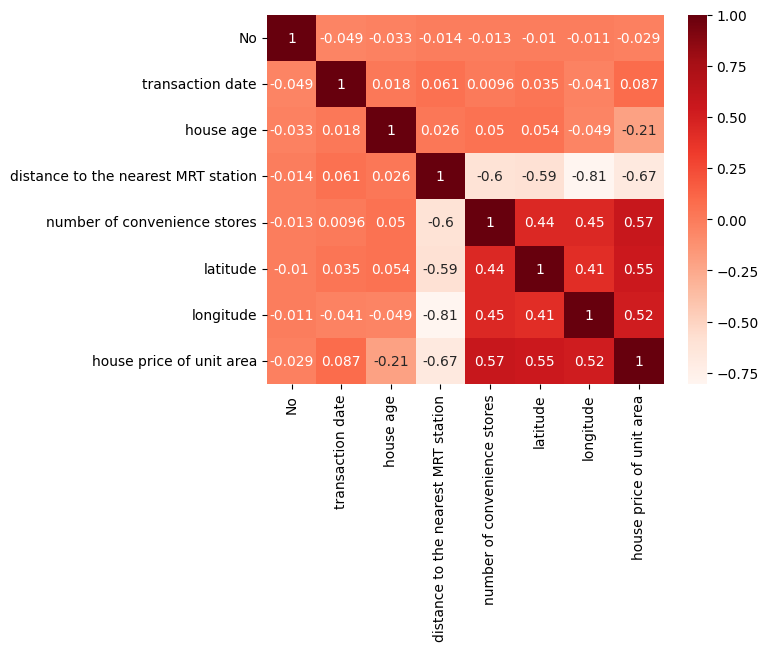

In [7]:
sns.heatmap(df.corr(), annot=True,cmap='Reds')

# 📊 Exploratory Data Analysis (EDA)

In [8]:
target = "house price of unit area"

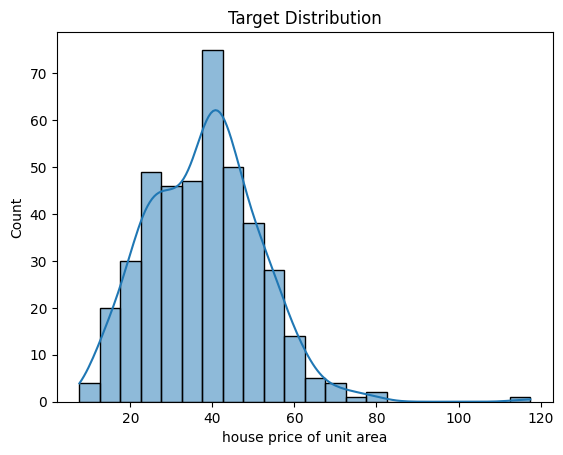

In [9]:
sns.histplot(df[target], kde=True)
plt.title("Target Distribution")
plt.show()

# Price vs Area

In [10]:
df['area'] = df['latitude'] * df['longitude']

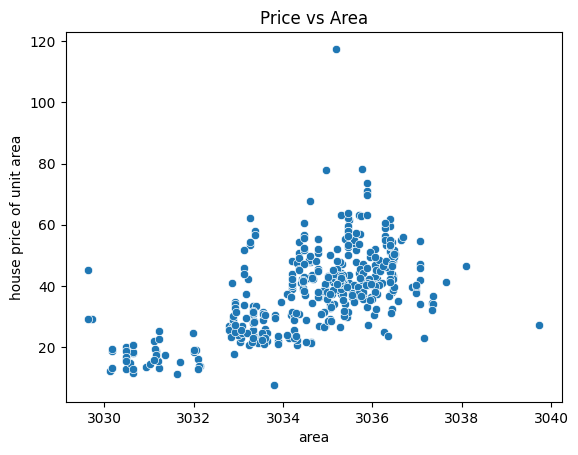

In [11]:
sns.scatterplot(x=df['area'], y=df['house price of unit area'])
plt.title("Price vs Area")
plt.show()

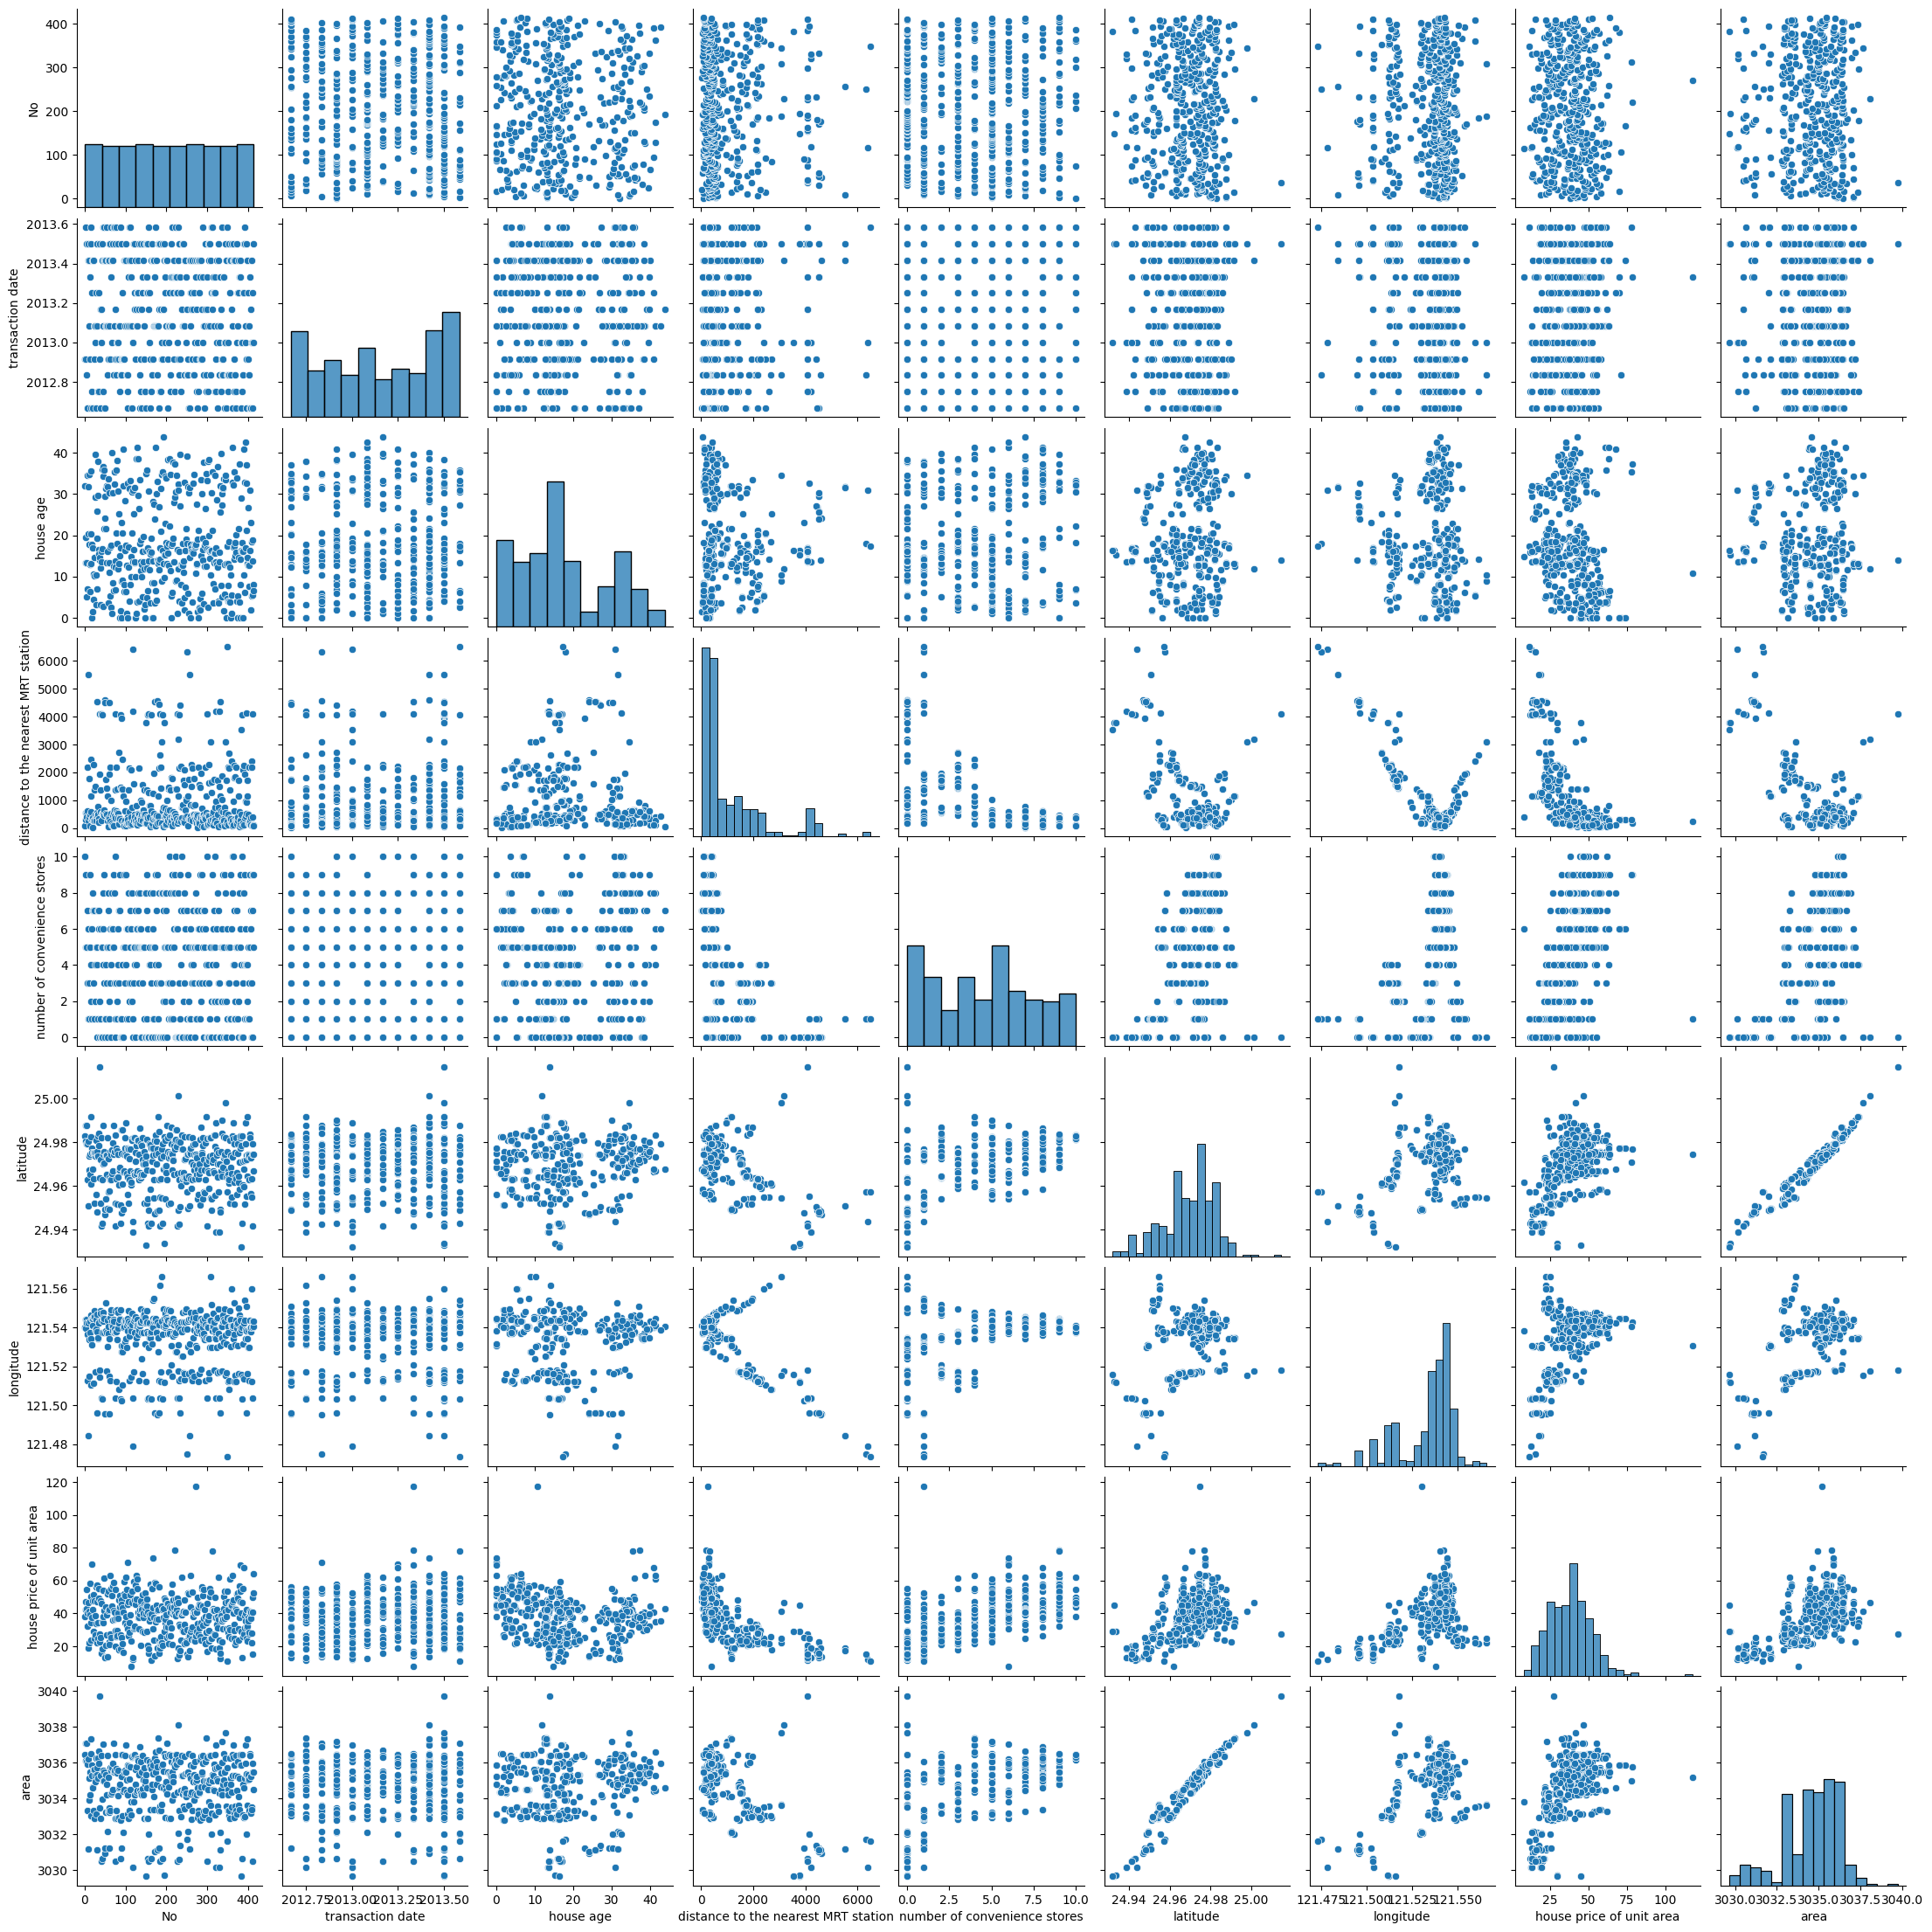

In [12]:
sns.pairplot(df)

## ✔️ Mulitple Linear Regression

In [9]:
cols_to_drop = ['house price of unit area', 'No', 'transaction date']

X = df.drop(columns=cols_to_drop)
y = df['house price of unit area']

In Python's data science libraries like NumPy and Pandas, axis=1 is used to specify that an operation should be performed across the columns (horizontally) for each individual row. 
Stack Overflow
Stack Overflow
 +1
While axis=0 refers to the vertical direction (acting down rows), axis=1 refers to the horizontal direction (acting across columns).

In [14]:
# alternate way to drop columns
# X = df.drop(['house price of unit area', 
#              'Number', 
#              'Transaction date'], axis=1)

In [15]:
# # another way of selecting features
# features = ['area', 'bedrooms', 'bathrooms']
# X = df[features]

# target = 'price'
# y = df[target]

In [10]:
print("X=",X.shape,"\ny=", y.shape)

X= (414, 5) 
y= (414,)


## Train Test Split

Now let's split the data into a training set and a testing set. We will train out model on the training set and then use the test set to evaluate the model.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

In [12]:
X_train.shape

(289, 5)

In [13]:
X_test.shape

(125, 5)

## Training the model

In [14]:
model = LinearRegression()

In [15]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = model.predict(X_test)

In [21]:
# Simple test: Use mean values for other features, vary only 'number of convenience stores'
mean_values = X_train.mean()

test_samples = pd.DataFrame({
    'house age': [mean_values['house age']],
    'distance to the nearest MRT station': [mean_values['distance to the nearest MRT station']],
    'number of convenience stores': [5],  # Change this value to test different inputs
    'latitude': [mean_values['latitude']],
    'longitude': [mean_values['longitude']]
})

predictions = model.predict(test_samples)
print(f"Prediction for convenience stores = {test_samples.iloc[0, 3]}: {predictions[0]:.2f}")

Prediction for convenience stores = 24.969585951557093: 39.34


## Compare Predictions vs Actual Values

In [ ]:
# Using your test set
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Error': y_test.values - y_pred
})
print(results_df.head(10))

   Actual     Predicted         Error
0       6  6.000000e+00 -1.154632e-14
1       5  5.000000e+00 -8.881784e-15
2       1  1.000000e+00 -1.465494e-14
3       1  1.000000e+00 -1.598721e-14
4       3  3.000000e+00 -7.993606e-15
5       8  8.000000e+00  9.769963e-15
6       5  5.000000e+00 -5.329071e-15
7       5  5.000000e+00  1.776357e-15
8       0 -4.236847e-15  4.236847e-15
9       9  9.000000e+00  8.881784e-15


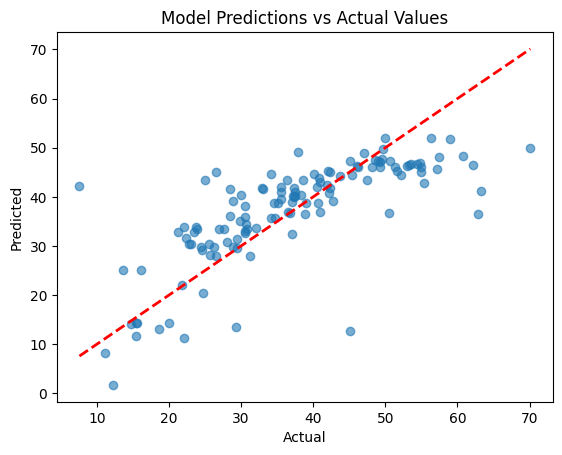

In [22]:
#  Display with Visualization
# Plot predictions vs actual values
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Model Predictions vs Actual Values')
plt.show()

## ✔️ Regression Evaluation Metrics


Here are three common evaluation metrics for regression problems:

> - **Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:
$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

> - **Mean Squared Error** (MSE) is the mean of the squared errors:
$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

> - **Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:
$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

> 📌 Comparing these metrics:
- **MAE** is the easiest to understand, because it's the average error.
- **MSE** is more popular than MAE, because MSE "punishes" larger errors, which tends to be useful in the real world.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.

> All of these are **loss functions**, because we want to minimize them.

In [ ]:
MAE= metrics.mean_absolute_error(y_test, y_pred)
MSE=metrics.mean_squared_error(y_test, y_pred)
RMSE= np.sqrt(MSE)

In [ ]:
MAE

6.5859759459914945e-15

In [ ]:
MSE

5.855933492340423e-29

In [ ]:
RMSE

np.float64(7.652407132622011e-15)

## **Residual Histogram**

* **Often for Linear Regression it is a good idea to separately evaluate residuals $$(y-\hat{y})$$ and not just calculate performance metrics (e.g. RMSE).**

* **Let's explore why this is important...**

* **The residual eerors should be random and close to a normal distribution.**


In [ ]:
test_residual= y_test - y_pred

In [ ]:
pd.DataFrame({'Error Values': (test_residual)}).hvplot.kde()

In [ ]:
sns.displot(test_residual, bins=25, kde=True)

* **Residual plot shows residual error VS. true y value.**

In [ ]:
sns.scatterplot(x=y_test, y=test_residual)

plt.axhline(y=0, color='r', ls='--')

* **Residualplot showing a clear pattern, indicating Linear Regression no valid!**

# Finished, but you can copy this notebook and start practicing.